                            AQI_Level  Temperature_C  Humidity_Pct
created_at                                                        
2024-04-06 12:00:00+05:30  162.620690      39.465517     33.491379
2024-04-06 13:00:00+05:30  165.140351      39.245614     33.233333
2024-04-06 14:00:00+05:30  168.627119      39.847458     33.374576
2024-04-06 15:00:00+05:30  163.724138      39.017241     33.434483
2024-04-06 16:00:00+05:30  166.465517      39.051724     33.734483
Recovering data from local storage...
Generating Anomaly Detection Plot...


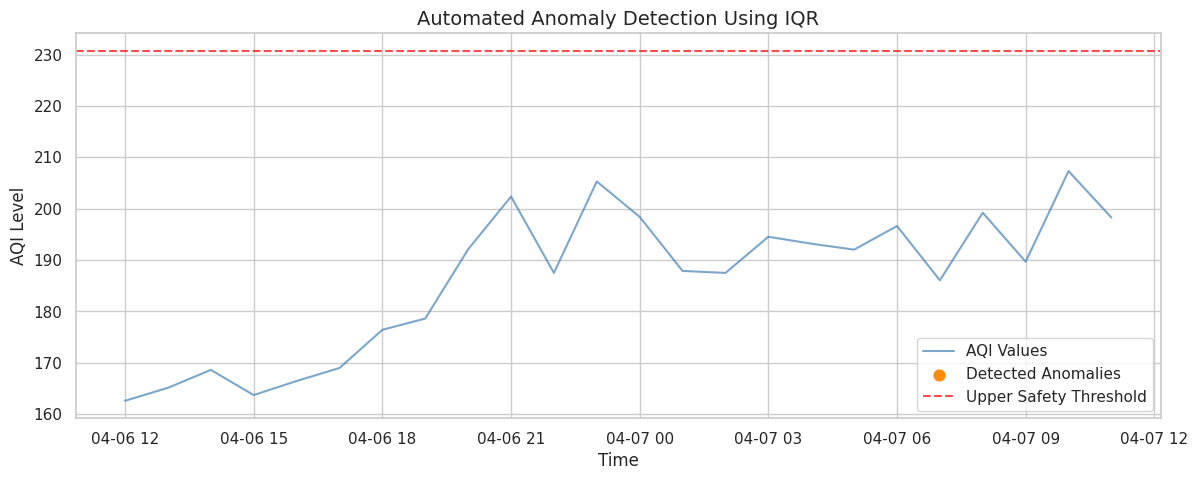

Training ARIMA Model (This may take a moment)...
Generating Actual vs Predicted Plot...


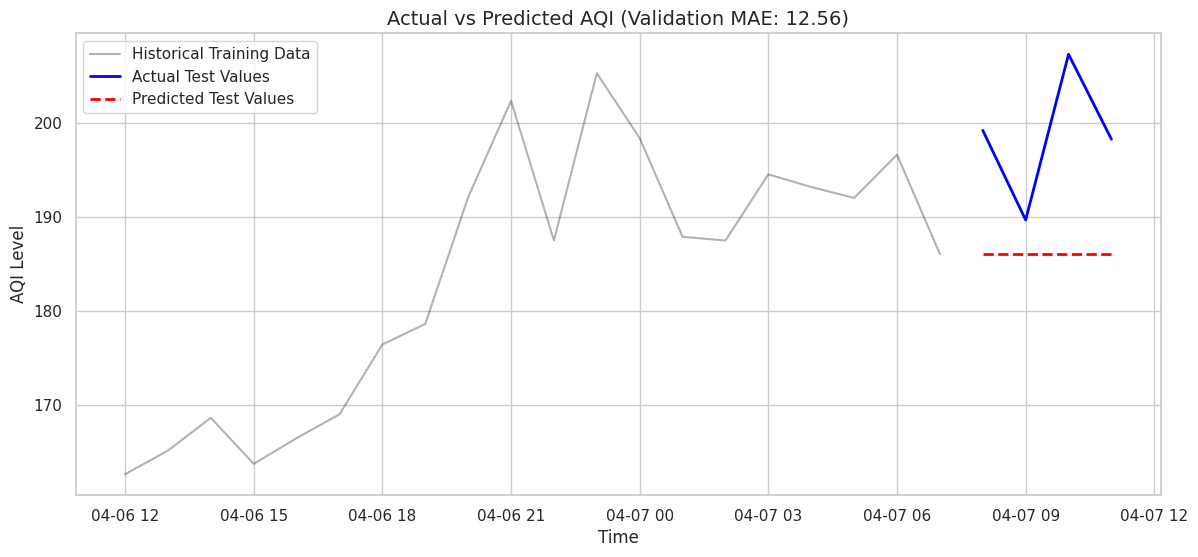

Generating 24-Hour Future Forecast...


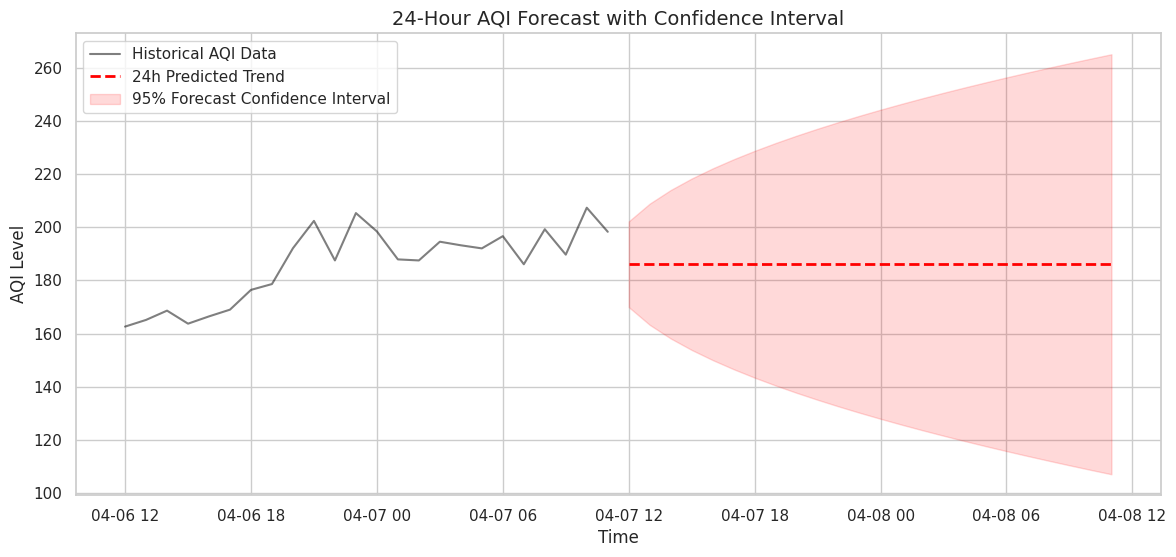

Analysis Complete. Found 0 anomalies.
Validation MAE: 12.56


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error

# Professional plotting style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. DATA RECOVERY & CLEANING
# ==========================================
local_path = 'UI/2026-04-06_131823_UTC/indoor_data.csv'

def get_clean_data(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Data not found at {path}. Please run your download cell.")
    
    df = pd.read_csv(path)
    df['created_at'] = pd.to_datetime(df['created_at'])
    df.set_index('created_at', inplace=True)

    # Keep needed columns, rename, resample hourly, and forward fill missing values
    cleaned = df[['field1', 'field2', 'field3']].rename(columns={
        'field1': 'AQI_Level',
        'field2': 'Temperature_C',
        'field3': 'Humidity_Pct'
    }).resample('h').mean().ffill()

    return cleaned

df_clean = get_clean_data('UI/2026-04-06_131823_UTC/indoor_data.csv')
print(df_clean.head())

# Recover hourly_data if variable was lost
if 'hourly_data' not in locals():
    print("Recovering data from local storage...")
    hourly_data = get_clean_data(local_path)

# ==========================================
# 2. VISUALIZATION 1: ANOMALY DETECTION (IQR)
# ==========================================
print("Generating Anomaly Detection Plot...")

Q1 = hourly_data['AQI_Level'].quantile(0.25)
Q3 = hourly_data['AQI_Level'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

anomalies = hourly_data[
    (hourly_data['AQI_Level'] < lower_bound) |
    (hourly_data['AQI_Level'] > upper_bound)
]

plt.figure(figsize=(14, 5))
plt.plot(
    hourly_data.index,
    hourly_data['AQI_Level'],
    label='AQI Values',
    color='steelblue',
    alpha=0.7
)
plt.scatter(
    anomalies.index,
    anomalies['AQI_Level'],
    color='darkorange',
    s=60,
    label='Detected Anomalies',
    zorder=5
)
plt.axhline(
    upper_bound,
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Upper Safety Threshold'
)
plt.title("Automated Anomaly Detection Using IQR", fontsize=14)
plt.xlabel("Time")
plt.ylabel("AQI Level")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 3. ARIMA MODEL TRAINING & VALIDATION
# ==========================================
print("Training ARIMA Model (This may take a moment)...")

target = hourly_data['AQI_Level']
train_size = int(len(target) * 0.85)
train = target.iloc[:train_size]
test = target.iloc[train_size:]

model = auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True)
test_predictions = model.predict(n_periods=len(test))
mae = mean_absolute_error(test, test_predictions)

# ==========================================
# 4. VISUALIZATION 2: ACTUAL VS PREDICTED (TEST SET)
# ==========================================
print("Generating Actual vs Predicted Plot...")

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label='Historical Training Data', color='black', alpha=0.3)
plt.plot(test.index, test, label='Actual Test Values', color='blue', linewidth=2)
plt.plot(test.index, test_predictions, label='Predicted Test Values', color='red', linestyle='--', linewidth=2)

plt.title(f"Actual vs Predicted AQI (Validation MAE: {mae:.2f})", fontsize=14)
plt.xlabel("Time")
plt.ylabel("AQI Level")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# ==========================================
# 5. VISUALIZATION 3: 24-HOUR FUTURE FORECAST
# ==========================================
print("Generating 24-Hour Future Forecast...")

future_forecast, conf_int = model.predict(n_periods=24, return_conf_int=True)

# Start forecast AFTER the last timestamp
future_dates = pd.date_range(
    start=target.index[-1] + pd.Timedelta(hours=1),
    periods=24,
    freq='h'
)

plt.figure(figsize=(14, 6))
plt.plot(target.index, target, label='Historical AQI Data', color='black', alpha=0.5)
plt.plot(future_dates, future_forecast, label='24h Predicted Trend', color='red', linestyle='--', linewidth=2)

plt.fill_between(
    future_dates,
    conf_int[:, 0],
    conf_int[:, 1],
    color='red',
    alpha=0.15,
    label='95% Forecast Confidence Interval'
)

plt.title("24-Hour AQI Forecast with Confidence Interval", fontsize=14)
plt.xlabel("Time")
plt.ylabel("AQI Level")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

print(f"Analysis Complete. Found {len(anomalies)} anomalies.")
print(f"Validation MAE: {mae:.2f}")

In [2]:
import joblib
import os

# Create a 'models' directory if it doesn't exist
model_dir = './models'
os.makedirs(model_dir, exist_ok=True)

# Define the file path
model_path = os.path.join(model_dir, 'aqi_arima_model.pkl')

# Save (serialize) the trained model
joblib.dump(model, model_path)

print(f"Model successfully saved to: {model_path}")

Model successfully saved to: ./models/aqi_arima_model.pkl


In [3]:
# Test loading the model
loaded_model = joblib.load('./models/aqi_arima_model.pkl')
print("Model loaded successfully!")
# Predict the next step to confirm it works
print(loaded_model.predict(n_periods=1))

Model loaded successfully!
2024-04-07 08:00:00+05:30    186.068966
Freq: h, dtype: float64
